In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np

from land_cover.load import plot_dir, loadGLAKES_GSWL, bawld_join_gswl_abz_filtered_pth, loadBAWLD, loadGreenness
from land_cover.plotting import reg_hexplot, plot_choro_and_hist

%load_ext autoreload
%autoreload 2

In [2]:
gdf = loadGLAKES_GSWL(filter_matches=False, region="na_abz", force_reload=True)

Drop variables that need to be rec computed on the Grid scale

In [3]:
gdf.drop(
    columns=[
        "occP1",
        "occP2",
        "occP3",
        "LEV_p1",
        "LEV_p2",
        "LEV_p3",
        "LEV_p13ain",
        "LEV_p13rin",
        "LEV_p23ain",
        "LEV_p23rin",
        "LEV_p13occ_ain",
        "LEV_p23occ_ain",
        "LEV_p13in",
    ],
    inplace=True,
)

In [4]:
gdf.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1549717 entries, 6 to 1878283
Data columns (total 72 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Lake_id_glakes        1549717 non-null  int64   
 1   Area_bound_glakes     1549717 non-null  float64 
 2   Area_PW_glakes        1549281 non-null  float64 
 3   Continent_glakes      1549717 non-null  object  
 4   Lat_glakes            1549717 non-null  float64 
 5   Lon_glakes            1549717 non-null  float64 
 6   GFed_flag_glakes      1549717 non-null  int64   
 7   PFed_flag_glakes      1549717 non-null  int64   
 8   Endo_flag_glakes      1549717 non-null  int64   
 9   Rser_flag_glakes      1549717 non-null  int64   
 10  Shape_Leng_glakes     1549717 non-null  float64 
 11  Shape_Area_glakes     1549717 non-null  float64 
 12  areaP1                331823 non-null   float64 
 13  areaP2                331823 non-null   float64 
 14  areaP3         

In [5]:
# compare nulls to greenness FYI: should be fewer non-nulls because NA ABZ only
greennessx2 = loadGreenness()

In [6]:
greennessx2.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 74 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Lake_id_glakes        1878284 non-null  int64   
 1   Area_bound_glakes     1878284 non-null  float64 
 2   Area_PW_glakes        1877185 non-null  float64 
 3   Continent_glakes      1878284 non-null  object  
 4   Lat_glakes            1878284 non-null  float64 
 5   Lon_glakes            1878284 non-null  float64 
 6   GFed_flag_glakes      1878284 non-null  int64   
 7   PFed_flag_glakes      1878284 non-null  int64   
 8   Endo_flag_glakes      1878284 non-null  int64   
 9   Rser_flag_glakes      1878284 non-null  int64   
 10  Shape_Leng_glakes     1878284 non-null  float64 
 11  Shape_Area_glakes     1878284 non-null  float64 
 12  areaP1                542298 non-null   float64 
 13  areaP2                542944 non-null   float64 
 14  areaP3    

In [7]:
gdf.head()

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,Zmax_gswl,Zmean_gswl,q_gswl,KG_gswl,LGM_gswl,area_km2_gswl,dyn_ratio_gswl,depth_ratio_gswl,match_gswl,geometry
6,24,6987.727526,6408.023451,North America,53.549500,-63.992625,0,1,0,1,...,5.517913,2.419782,1.526856,27.0,ice,0.202558,0.185994,0.438532,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5..."
10,40,4869.707306,4491.280258,North America,66.495447,-70.561392,0,1,0,0,...,4.250686,1.855246,1.279398,27.0,ice,0.109341,0.178234,0.436458,0.0,"MULTIPOLYGON (((-70.77548 66.92143, -70.77575 ..."
12,47,4445.288180,4307.917229,North America,49.823532,-88.517557,0,0,0,1,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-88.38025 50.2885, -88.3805 50..."
13,48,4362.538872,3844.535752,North America,54.042750,-69.254000,0,1,0,1,...,14.758257,5.384435,1.475450,27.0,ice,2.284907,0.280733,0.364842,0.0,"MULTIPOLYGON (((-69.4725 54.89075, -69.4725 54..."
15,57,3542.349852,3321.742907,North America,63.113516,-101.407247,0,1,0,0,...,4.776712,1.994000,1.237994,27.0,ice,0.020241,0.071350,0.417442,0.0,"MULTIPOLYGON (((-100.668 63.41525, -100.668 63..."


# Join BAWLD and aggregate over its grid cells

In [95]:
# Grid to BAWLD grid to plot prevelance rel to non-selected lakes
gdf_bawld = loadBAWLD()
gdf_bawld_for_join = gdf_bawld[["Cell_ID_bawld", "geometry"]]

In [9]:
gdf.columns

Index(['Lake_id_glakes', 'Area_bound_glakes', 'Area_PW_glakes',
       'Continent_glakes', 'Lat_glakes', 'Lon_glakes', 'GFed_flag_glakes',
       'PFed_flag_glakes', 'Endo_flag_glakes', 'Rser_flag_glakes',
       'Shape_Leng_glakes', 'Shape_Area_glakes', 'areaP1', 'areaP2', 'areaP3',
       'NDVI8499', 'NDVI0010', 'NDVI1121', 'vegeP1', 'validP1', 'vegeP2',
       'validP2', 'vegeP3', 'validP3', 'area_1984_1999_wm',
       'area_2000_2009_wm', 'area_2010_2019_wm', 'max_bound_dist',
       'mean_bound_dist', 'Hylak_id', 'Lake_name_hylak', 'Country_hylak',
       'Continent_hylak', 'Poly_src_hylak', 'Lake_type_hylak',
       'Grand_id_hylak', 'Lake_area_hylak', 'Shore_len_hylak',
       'Shore_dev_hylak', 'Vol_total_hylak', 'Vol_res_hylak', 'Vol_src_hylak',
       'Depth_avg_hylak', 'Dis_avg_hylak', 'Res_time_hylak', 'Elevation_hylak',
       'Slope_100_hylak', 'Wshd_area_hylak', 'Pour_long_hylak',
       'Pour_lat_hylak', 'sen_slope', 'mann_kendall_trend',
       'trend_significance', 'b

In [96]:
gdf_bawld.columns

Index(['Area_km2', 'Temp_K', 'LEV_MEAN_km2_k23', 'LEV_MIN_km2_k23',
       'LEV_MAX_km2_k23', 'est_mg_m2_day_k23', 'est_g_day_k23',
       'lake_count_k23', 'LEV_MEAN_frac_k23', 'LEV_MIN_frac_k23',
       'LEV_MAX_frac_k23', 'Cell_ID_bawld', 'Long_bawld', 'Lat_bawld',
       'Area_Pct_bawld', 'Shp_Area_bawld', 'GLA', 'ROC', 'TUN', 'BOR', 'WET',
       'PEB', 'WTU', 'MAR', 'BOG', 'FEN', 'LAK', 'LAL', 'MPL', 'MYL', 'MGL',
       'SPL', 'SYL', 'SGL', 'RIV', 'LAR', 'SRR', 'SRP', 'WETSCAPE',
       'LEV_MEAN_grid_frac_k23', 'LEV_MIN_grid_frac_k23',
       'LEV_MAX_grid_frac_k23', 'geometry'],
      dtype='object')

In [11]:
# temp dataset for join
_gdf_points = (
    gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf["Lon_glakes"], gdf["Lat_glakes"]),
        crs=gdf.crs,
    )
    .drop(columns=["index_right"])
    .to_crs(gdf_bawld.crs)
)

<Axes: >

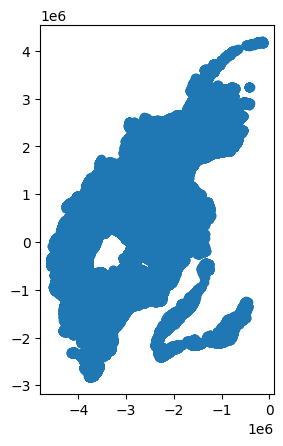

In [11]:
_gdf_points.plot()

In [97]:
# aggregate
gdf_joined = gpd.sjoin(gdf_bawld_for_join, _gdf_points, how="left", predicate="contains")

In [98]:
gdf_joined.info(max_cols=500, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1565358 entries, 0 to 23468
Data columns (total 73 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Cell_ID_bawld         1565358 non-null  int64   
 1   geometry              1565358 non-null  geometry
 2   index_right           1549693 non-null  float64 
 3   Lake_id_glakes        1549693 non-null  float64 
 4   Area_bound_glakes     1549693 non-null  float64 
 5   Area_PW_glakes        1549257 non-null  float64 
 6   Continent_glakes      1549693 non-null  object  
 7   Lat_glakes            1549693 non-null  float64 
 8   Lon_glakes            1549693 non-null  float64 
 9   GFed_flag_glakes      1549693 non-null  float64 
 10  PFed_flag_glakes      1549693 non-null  float64 
 11  Endo_flag_glakes      1549693 non-null  float64 
 12  Rser_flag_glakes      1549693 non-null  float64 
 13  Shape_Leng_glakes     1549693 non-null  float64 
 14  Shape_Area_glakes

Aggregate

In [99]:
# slow version to ensure nanmean
from pandas.api.types import is_float_dtype
gdf_sjoin = gpd.sjoin(gdf_bawld_for_join, _gdf_points, how="left", predicate="contains")

def my_nanmean(s):
    return np.nanmean(s)


def my_nansum(s):
    return np.nansum(s)


# future numpy: just use function np.nanmean
agg_map = {
    col: (my_nanmean if is_float_dtype(gdf_sjoin[col]) else "first") for col in gdf_sjoin.columns
}
agg_map["geometry"] = "first"  # ensure geometry isn't sent to np dtypes
sum_vars = [
    "areaP1",
    "areaP2",
    "areaP3",
    "area_1984_1999_wm",
    "area_2000_2009_wm",
    "area_2010_2019_wm",
    "vegeP1",
    "validP1",
    "vegeP2",
    "validP2",
    "vegeP3",
    "validP3",
    "Area_PW_glakes",
]
for col in sum_vars:
    agg_map[col] = my_nansum

gdf_regridded = gdf_sjoin.groupby("Cell_ID_bawld", as_index=False).agg(agg_map)
gdf_regridded = gdf_regridded.merge(
    gdf_bawld.drop(columns="geometry"), on="Cell_ID_bawld"
)
gdf_regridded.drop(columns="index_right", inplace=True)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_84182/4182687334.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(s)


In [100]:
# compute LEV on grid cells
# water area
area_vars = [
    "area_1984_1999_wm",
    "area_2000_2009_wm",
    "area_2010_2019_wm",
]
for i, n in enumerate([1,2,3]):
    gdf_regridded[f"AV_per_p{n}_liu_regrid"] = gdf_regridded[f"areaP{n}"] / gdf_regridded.Shp_Area_bawld * 1e9 * 100
    # For indiv lakes, I would use area_max, but for grid cell agg, Area_PW_glakes is fine
    gdf_regridded[f"LEV_p{n}_liu_regrid"] = (
        gdf_regridded[f"areaP{n}"] / gdf_regridded["Area_PW_glakes"] * 100  # gdf_regridded[area_vars[i]] * 100
    )

# Lake area over time
gdf_regridded["Water_change_p1p2_regrid"] = (
    gdf_regridded["area_2000_2009_wm"] - gdf_regridded["area_1984_1999_wm"]
)
gdf_regridded["Water_change_p1p3_regrid"] = (
    gdf_regridded["area_2010_2019_wm"] - gdf_regridded["area_1984_1999_wm"]
)
gdf_regridded["Water_change_p2p3_regrid"] = (
    gdf_regridded["area_2010_2019_wm"] - gdf_regridded["area_2000_2009_wm"]
)

# MA over time
gdf_regridded["AV_change_p1p2_liu_regrid"] = gdf_regridded["areaP2"] - gdf_regridded["areaP1"]
gdf_regridded["AV_change_p1p3_liu_regrid"] = gdf_regridded["areaP3"] - gdf_regridded["areaP1"]
gdf_regridded["AV_change_p2p3_liu_regrid"] = gdf_regridded["areaP3"] - gdf_regridded["areaP2"]

# MA over time, relative to lake area
gdf_regridded["LEV_change_p1p2_liu_regrid"] = (
    gdf_regridded["LEV_p2_liu_regrid"] - gdf_regridded["LEV_p1_liu_regrid"]
)
gdf_regridded["LEV_change_p1p3_liu_regrid"] = (
    gdf_regridded["LEV_p3_liu_regrid"] - gdf_regridded["LEV_p1_liu_regrid"]
)
gdf_regridded["LEV_change_p2p3_liu_regrid"] = (
    gdf_regridded["LEV_p3_liu_regrid"] - gdf_regridded["LEV_p2_liu_regrid"]
)

# MA over time, units of % change in AV area
gdf_regridded["AV_pchange_p1p2_liu_regrid"] = (
    gdf_regridded["area_2000_2009_wm"] - gdf_regridded["area_1984_1999_wm"]
) / gdf_regridded["area_1984_1999_wm"] * 100
gdf_regridded["AV_pchange_p1p3_liu_regrid"] = (
    gdf_regridded["area_2010_2019_wm"] - gdf_regridded["area_1984_1999_wm"]
) / gdf_regridded["area_1984_1999_wm"] * 100
gdf_regridded["AV_pchange_p2p3_liu_regrid"] = (
    gdf_regridded["area_2010_2019_wm"] - gdf_regridded["area_2000_2009_wm"]
) / gdf_regridded["area_2000_2009_wm"] * 100

In [101]:
# Compute Occ
veg_observation_vars = [
    "vegeP1",
    "vegeP2",
    "vegeP3",
]
valid_observation_vars = [
    "validP1",
    "validP2",
    "validP3",
]
for i, n in enumerate([1,2,3]):
    gdf_regridded[f"AV_Occ_p{n}_liu_regrid"] = (
        gdf_regridded[f"vegeP{n}"] / gdf_regridded[f"validP{n}"] * 100
    )

# Change in occ over time
gdf_regridded["AV_Occ_change_p1p2_liu_regrid"] = (
    gdf_regridded["AV_Occ_p2_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
)
gdf_regridded["AV_Occ_change_p1p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
)
gdf_regridded["AV_Occ_change_p2p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p2_liu_regrid"]
)

# relative percent change in VO
gdf_regridded["AV_Occ_pchange_p1p2_liu_regrid"] = (
    gdf_regridded["AV_Occ_p2_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
) / gdf_regridded["AV_Occ_p1_liu_regrid"] * 100
gdf_regridded["AV_Occ_pchange_p1p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
) / gdf_regridded["AV_Occ_p1_liu_regrid"] * 100
gdf_regridded["AV_Occ_pchange_p2p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p2_liu_regrid"]
) / gdf_regridded["AV_Occ_p2_liu_regrid"] * 100

Compute weighted mean

In [102]:
# Compute weighted mean
results = []
weighted_mean_vars = ["b2_mean", "sen_slope", "NDVI8499", "NDVI0010", "NDVI1121"]
for var in weighted_mean_vars:
    df_tmp = gdf_sjoin[[var, "Cell_ID_bawld", "Area_PW_glakes"]].dropna()
    df_grouped = df_tmp.groupby("Cell_ID_bawld", as_index=False).apply(
        lambda g: (
            np.average(g[var], weights=g["Area_PW_glakes"])
            if g["Area_PW_glakes"].notna().any()
            else np.nan
        )
    )
    df_grouped = df_grouped.rename(columns={None: f"{var}_wmean"})
    results.append(df_grouped)

df_weighted = results[0]
for df_next in results[1:]:
    df_weighted = df_weighted.merge(df_next, on="Cell_ID_bawld", how="outer")

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_84182/942554089.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_tmp.groupby("Cell_ID_bawld", as_index=False).apply(
/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_84182/942554089.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_tmp.groupby("Cell_ID_bawld", as_index=False).apply(
/var/folders/rv/sn0k

In [103]:
# Merge in weighted mean
gdf_regridded = gdf_regridded.merge(df_weighted, "left", on="Cell_ID_bawld", validate="1:1").drop(
    columns=weighted_mean_vars
)

In [104]:
# Compute NDVI change (simple avg)

gdf_regridded["NDVI_p1p2_liu_regrid"] = (
    gdf_regridded["NDVI0010_wmean"] - gdf_regridded["NDVI8499_wmean"]
)
gdf_regridded["NDVI_p1p3_liu_regrid"] = (
    gdf_regridded["NDVI1121_wmean"] - gdf_regridded["NDVI8499_wmean"]
)
gdf_regridded["NDVI_p2p3_liu_regrid"] = (
    gdf_regridded["NDVI1121_wmean"] - gdf_regridded["NDVI0010_wmean"]
)

In [105]:
# rm inf

gdf_regridded = gdf_regridded.replace([np.inf, -np.inf], np.nan)

In [106]:
gdf_regridded = gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs)

In [107]:
gdf_regridded.info(max_cols=500, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23469 entries, 0 to 23468
Data columns (total 143 columns):
 #    Column                          Non-Null Count  Dtype   
---   ------                          --------------  -----   
 0    Cell_ID_bawld                   23469 non-null  int64   
 1    geometry                        23469 non-null  geometry
 2    Lake_id_glakes                  7804 non-null   float64 
 3    Area_bound_glakes               7804 non-null   float64 
 4    Area_PW_glakes                  23469 non-null  float64 
 5    Continent_glakes                7804 non-null   object  
 6    Lat_glakes                      7804 non-null   float64 
 7    Lon_glakes                      7804 non-null   float64 
 8    GFed_flag_glakes                7804 non-null   float64 
 9    PFed_flag_glakes                7804 non-null   float64 
 10   Endo_flag_glakes                7804 non-null   float64 
 11   Rser_flag_glakes                7804 non-null   float64 


In [108]:
bawld_join_gswl_abz_filtered_pth

PosixPath('/Volumes/metis/ABOVE3/other_outputs/BAWLD_GLAKES_gswl_filtered.gpkg')

In [109]:
# export to QGIS (ignore "filtered" in path, it refers to NA ABZ)
gdf_regridded.to_file(bawld_join_gswl_abz_filtered_pth)

Sanity check

count    7800.000000
mean       53.245889
std        45.965891
min         0.000000
25%         0.000000
50%        60.511779
75%       100.000000
max       100.000000
Name: LEV_p3_liu_regrid, dtype: float64

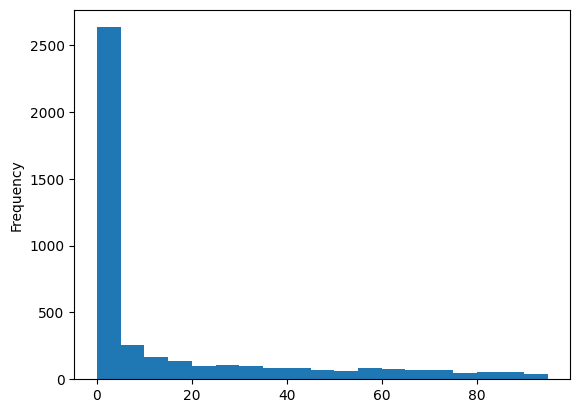

In [192]:
gdf_regridded.LEV_p3_liu_regrid.plot.hist(bins=np.arange(0, 100, 5))
gdf_regridded.LEV_p3_liu_regrid.clip(0,100).describe()

## Chloropleth and hist plots to verify data

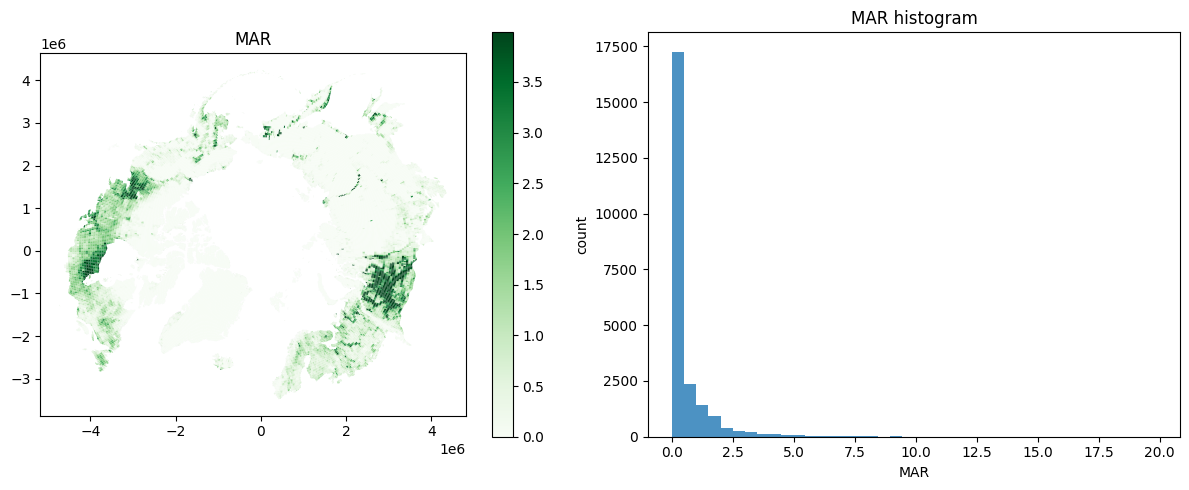

In [62]:
_, _ = plot_choro_and_hist(gdf_regridded, "MAR")

NDVI is increasing (weighted avg)

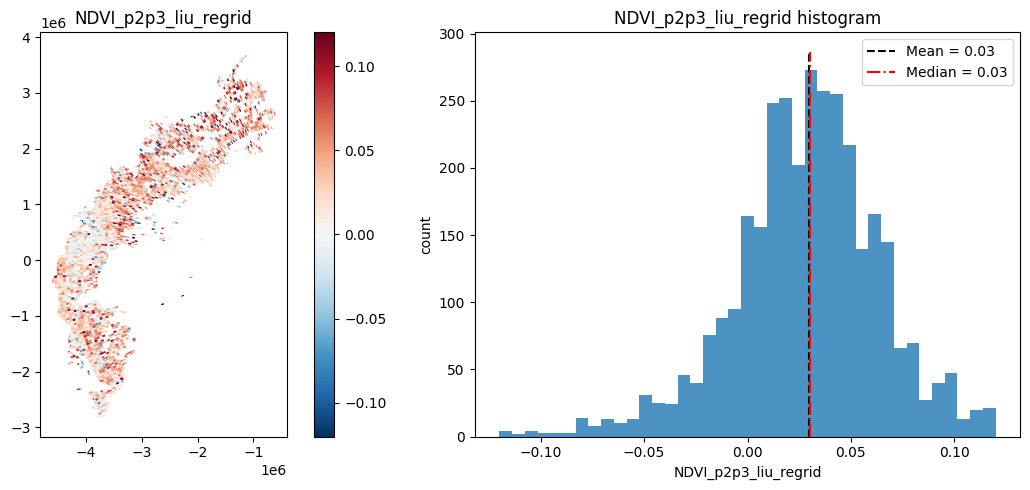

In [88]:
_, _ = plot_choro_and_hist(gdf_regridded, "NDVI_p2p3_liu_regrid", hist_stats=True)

Masked to NA Kuhn domain: NDVI is still increasing

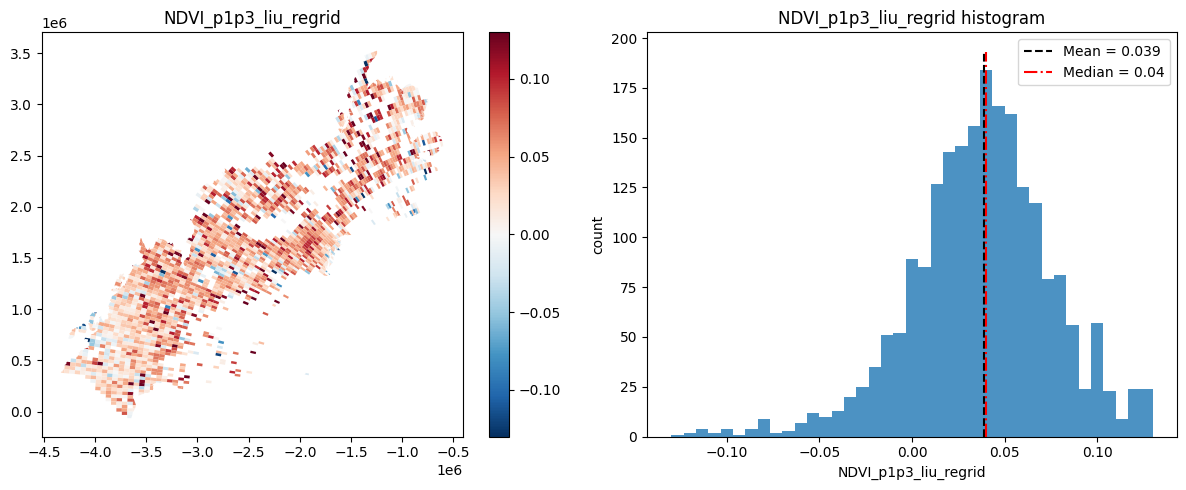

In [92]:
_, _ = plot_choro_and_hist(
    gdf_regridded[np.isfinite(gdf_regridded.sen_slope_wmean)], "NDVI_p1p3_liu_regrid", hist_stats=True
)

Greenness is decreasing (simple avg, unequal aggregation first to GLAKES)

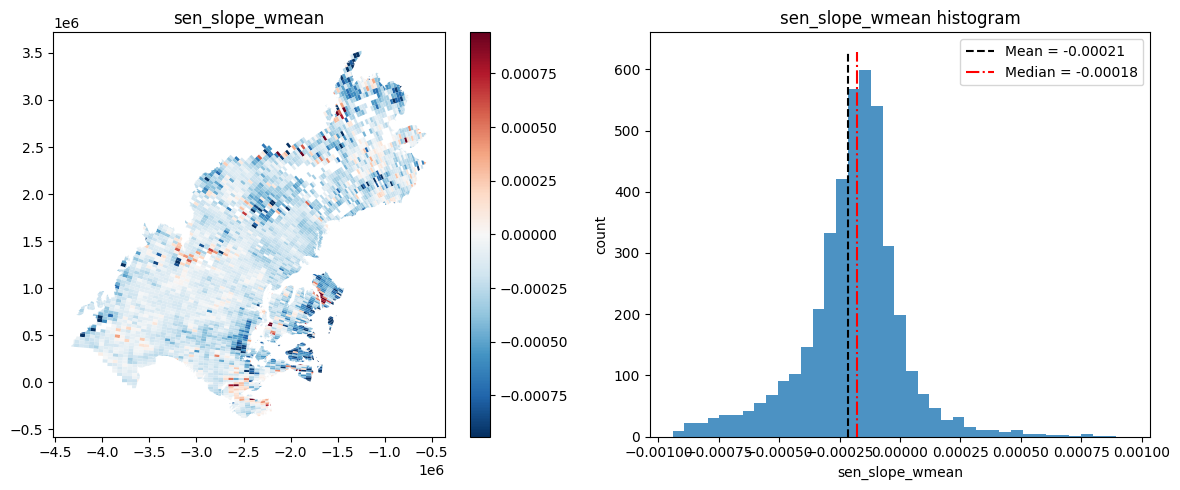

In [91]:
_, _ = plot_choro_and_hist(gdf_regridded, "sen_slope_wmean", hist_stats=True)

### Other static vars

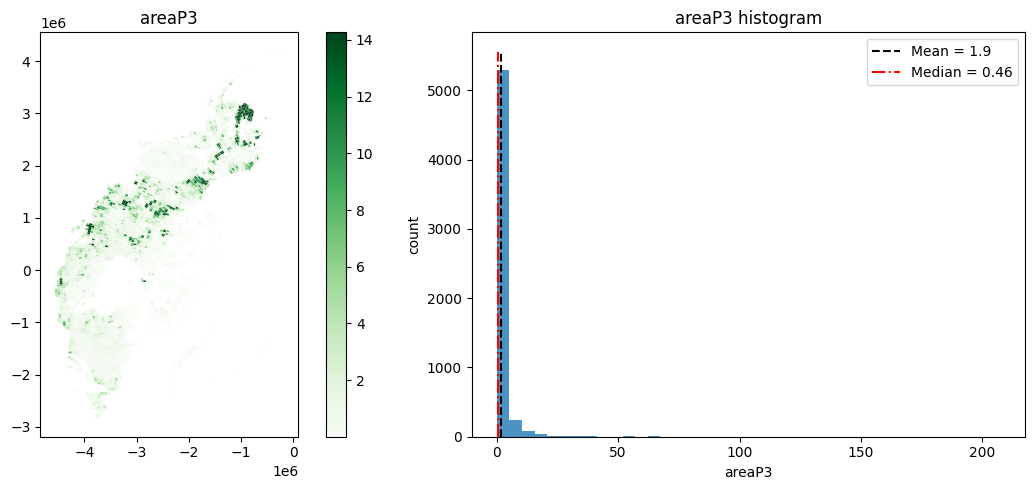

In [90]:
_, _ = plot_choro_and_hist(gdf_regridded[gdf_regridded["LEV_p3_liu_regrid"] > 0], "areaP3", hist_stats=True)

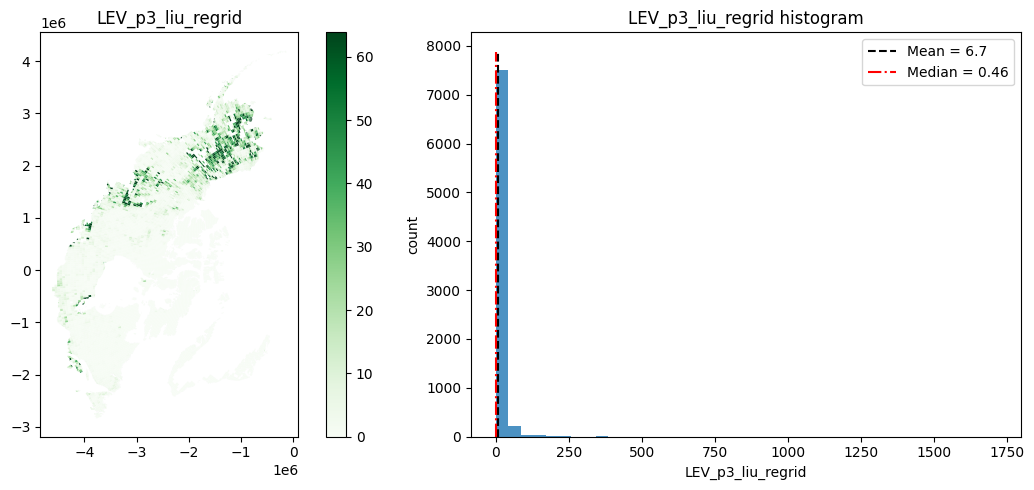

In [79]:
_, _ = plot_choro_and_hist(gdf_regridded, "LEV_p3_liu_regrid", hist_stats=True)

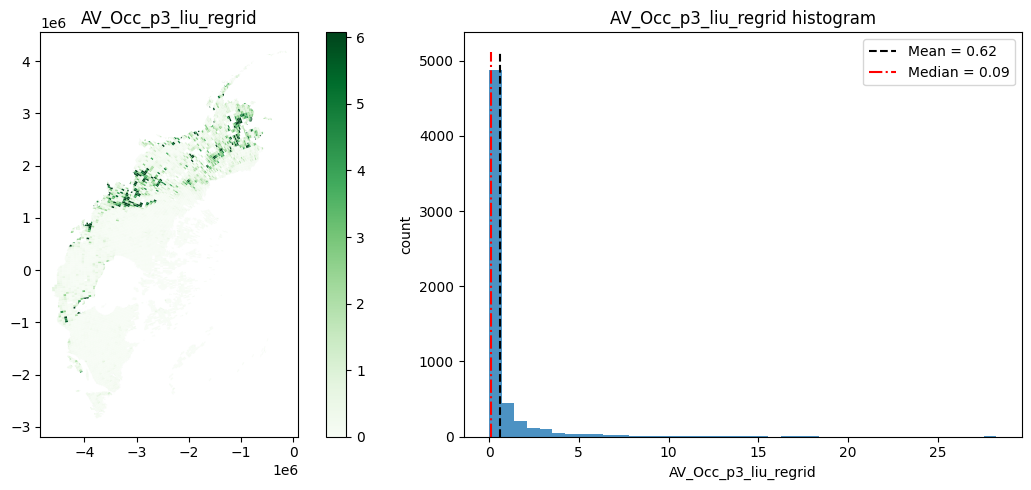

In [86]:
_, _ = plot_choro_and_hist(gdf_regridded, "AV_Occ_p3_liu_regrid", hist_stats=True)

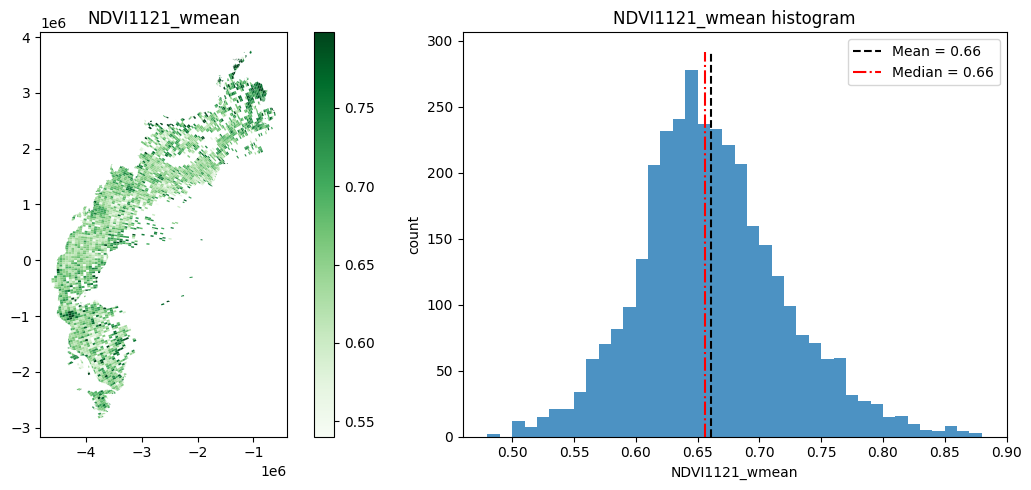

In [87]:
_, _ = plot_choro_and_hist(gdf_regridded, "NDVI1121_wmean", hist_stats=True)

Same areas pop out with my K23 estimate! AK, HBL, Peace/Slave/Mack/Sask Rivers and Deltas. Low – valued areas appear to be overestimated in mine.

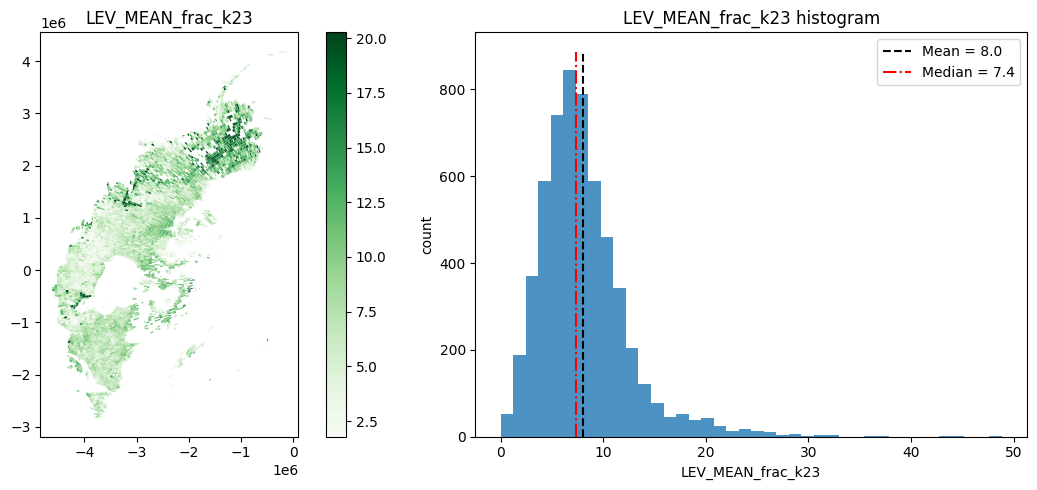

In [85]:
_, _ = plot_choro_and_hist(
    gdf_regridded[gdf_regridded["LEV_p3_liu_regrid"] > 0], "LEV_MEAN_frac_k23", hist_stats=True
)

Other change vars

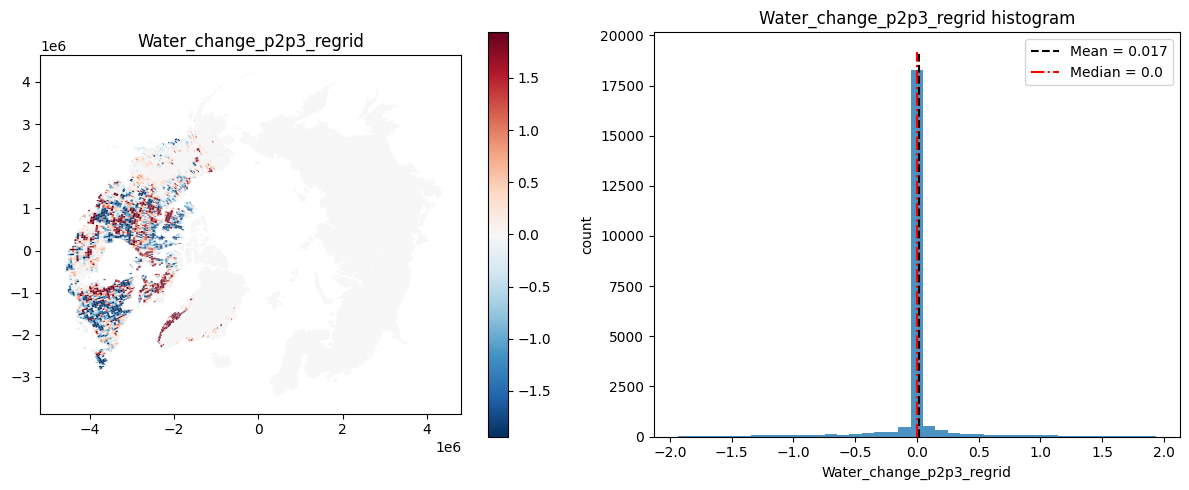

In [105]:
# water units: km2
_, _ = plot_choro_and_hist(gdf_regridded, "Water_change_p2p3_regrid", hist_stats=True)

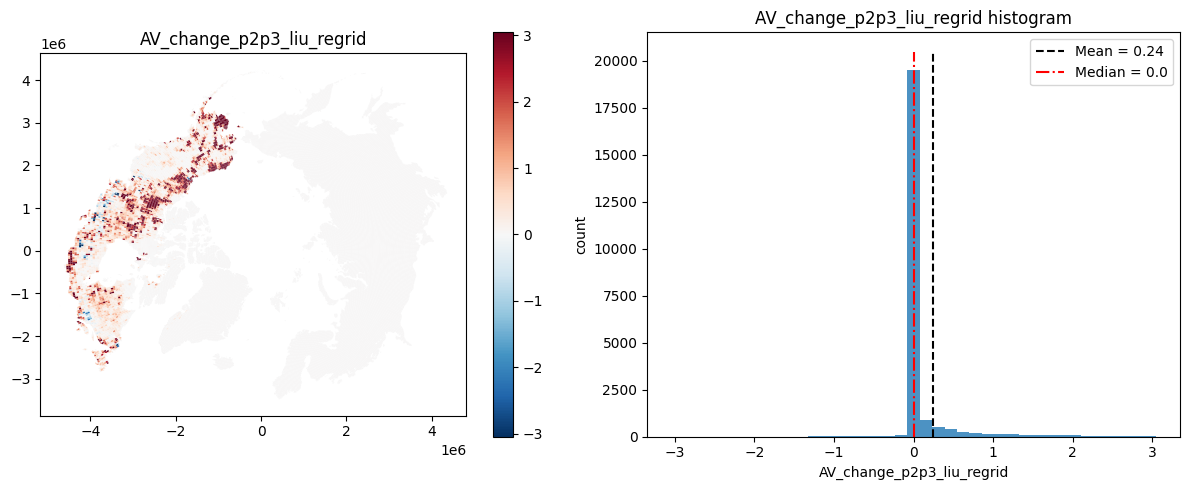

In [ ]:
# AV units: km2
_, _ = plot_choro_and_hist(gdf_regridded, "AV_change_p2p3_liu_regrid", hist_stats=True)

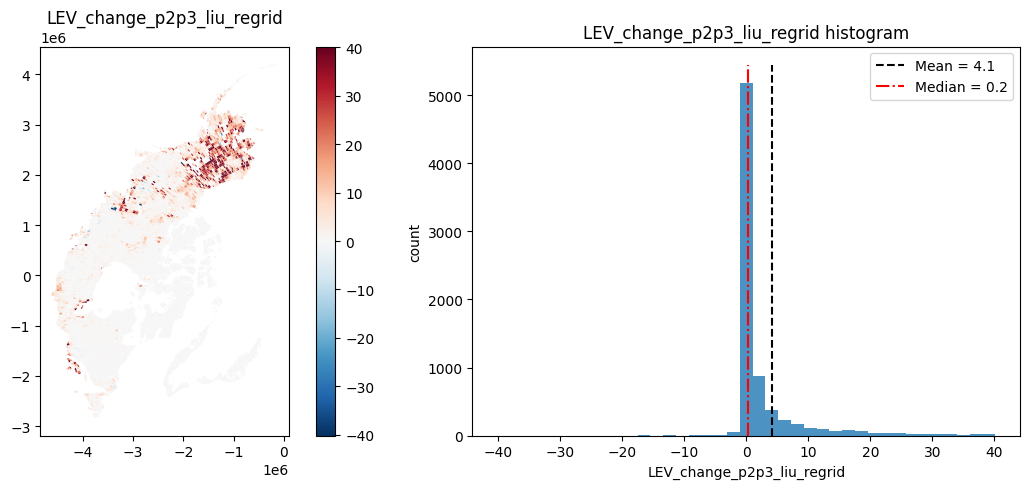

In [ ]:
# LEV comes from MA
_, _ = plot_choro_and_hist(gdf_regridded, "LEV_change_p2p3_liu_regrid", hist_stats=True)

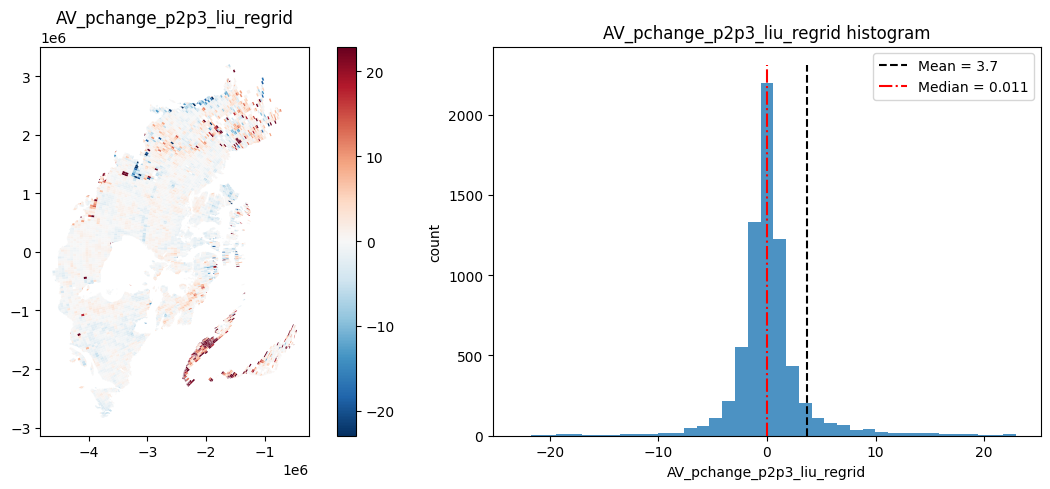

In [81]:
# Areas with little LEV to begin with can still be highlighted
_, _ = plot_choro_and_hist(gdf_regridded, "AV_pchange_p2p3_liu_regrid", hist_stats=True)

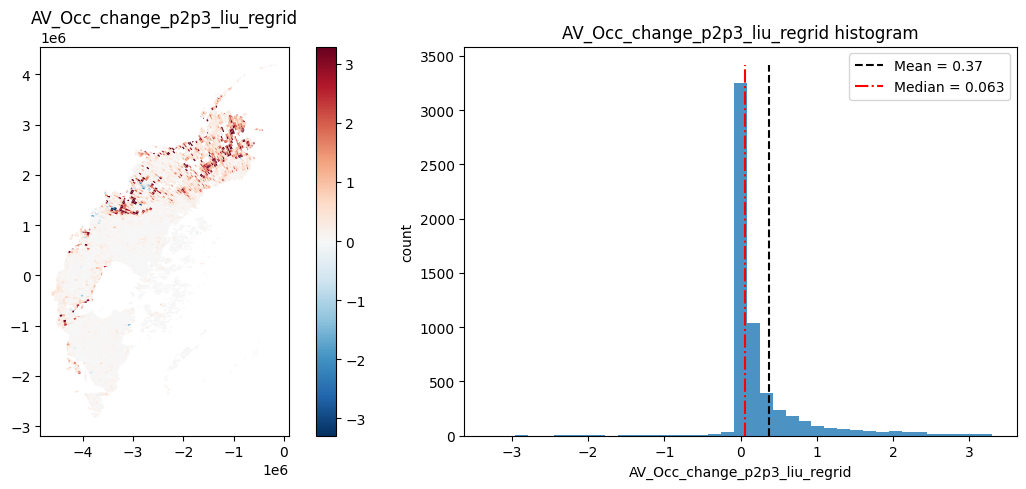

In [82]:
_, _ = plot_choro_and_hist(gdf_regridded, "AV_Occ_change_p2p3_liu_regrid", hist_stats=True)

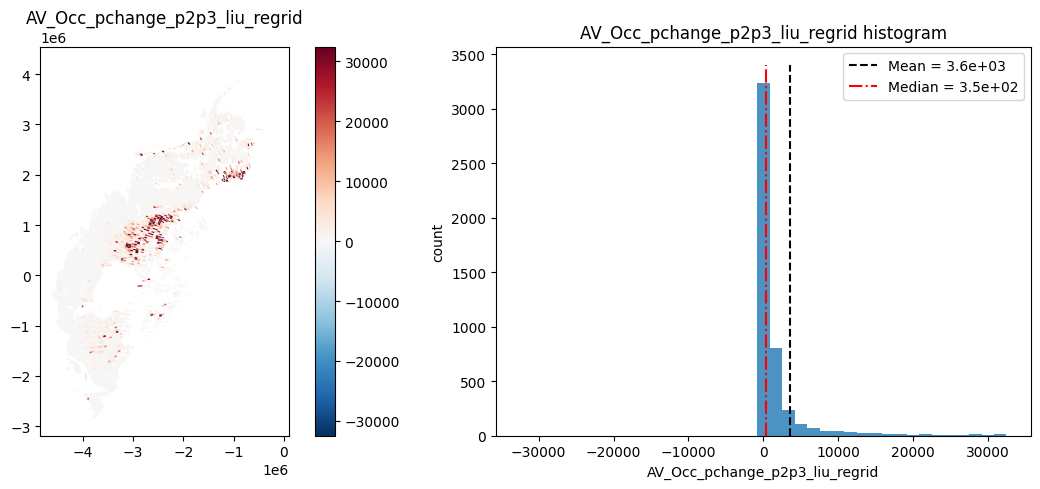

In [83]:
_, _ = plot_choro_and_hist(gdf_regridded, "AV_Occ_pchange_p2p3_liu_regrid", hist_stats=True)

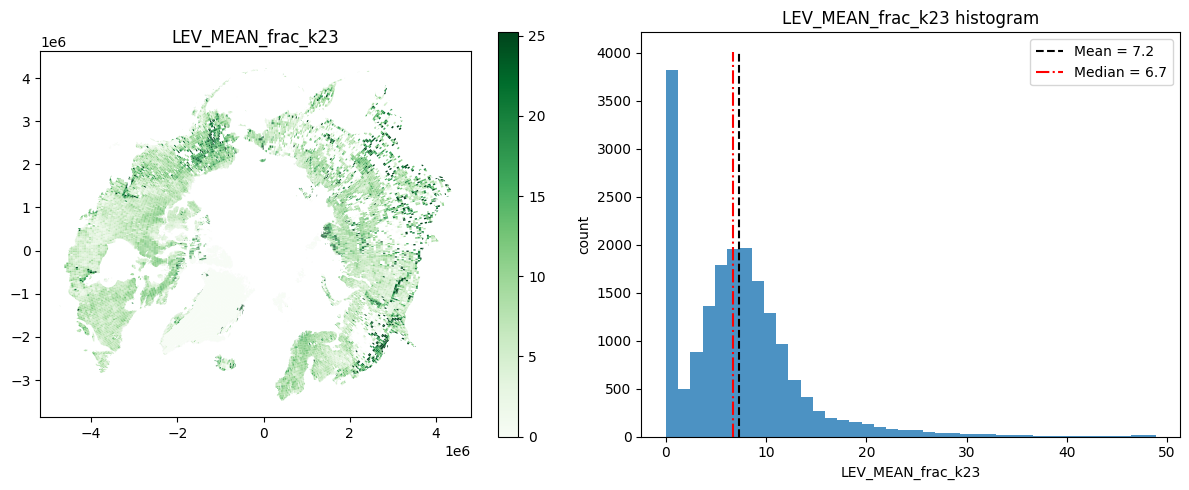

In [ ]:
_, _ = plot_choro_and_hist(gdf_regridded, "LEV_MEAN_frac_k23", hist_stats=True)

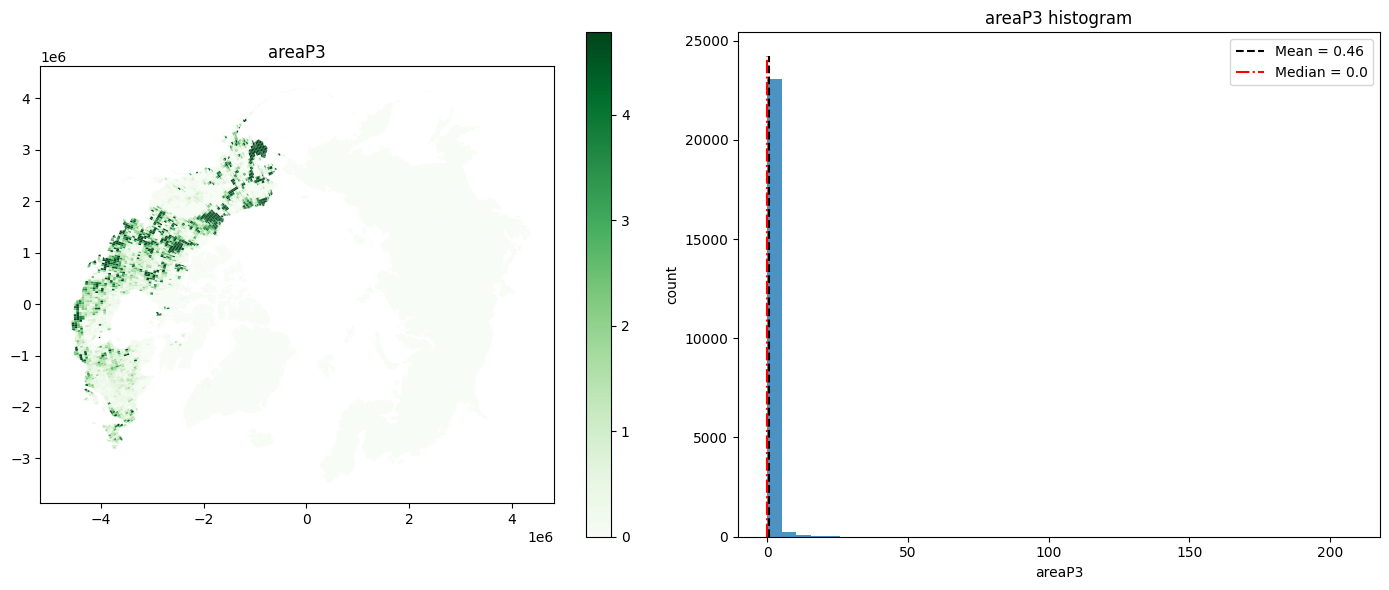

In [ ]:
_, _ = plot_choro_and_hist(gdf_regridded, "areaP3", hist_stats=True)

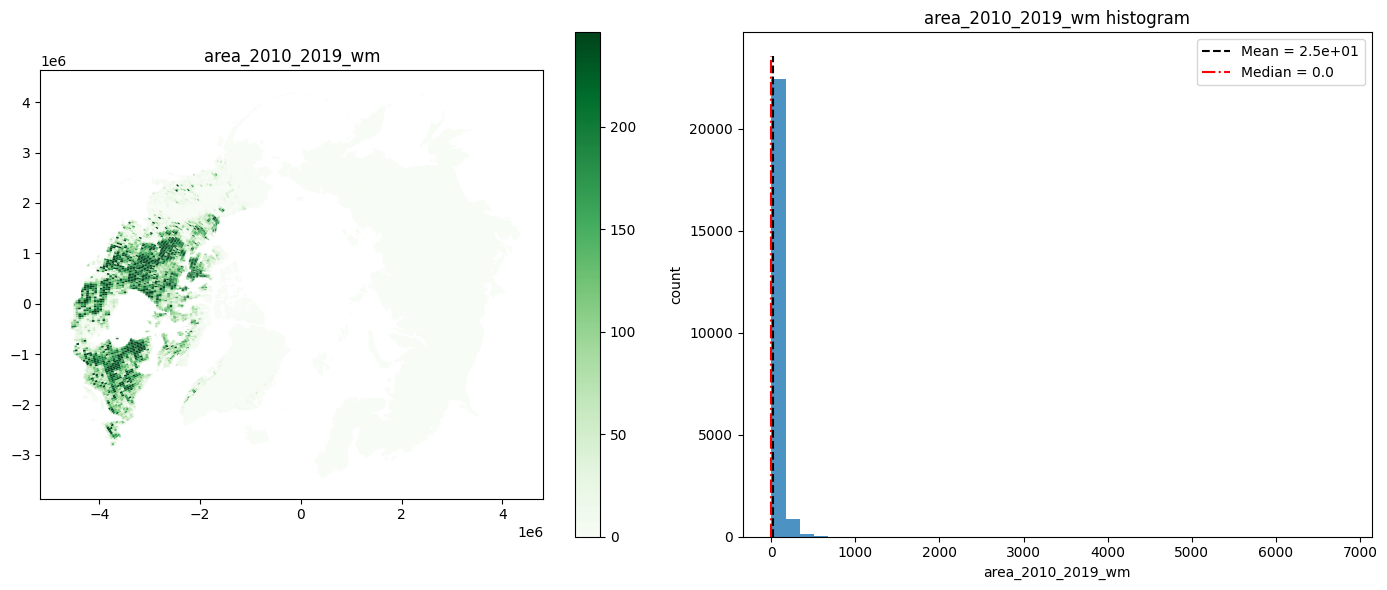

In [59]:
_, _ = plot_choro_and_hist(gdf_regridded, "area_2010_2019_wm", hist_stats=True)

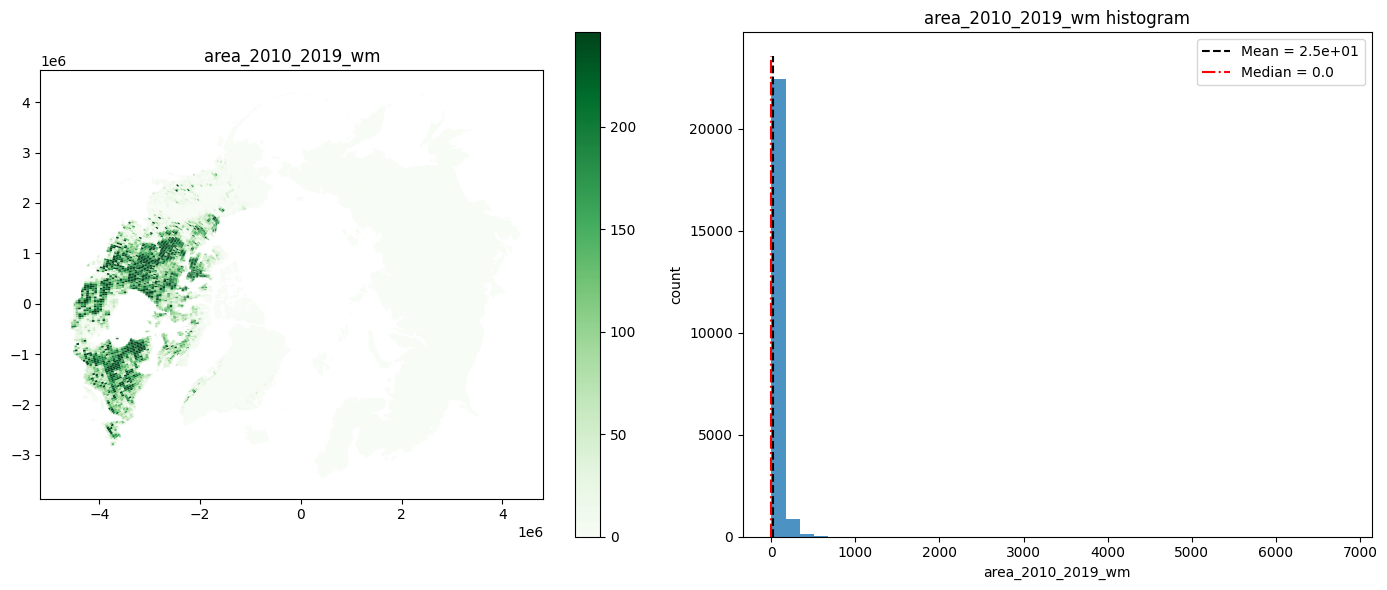

In [ ]:
_, _ = plot_choro_and_hist(gdf_regridded, "area_2010_2019_wm", hist_stats=True)

Test (can rm)

In [55]:
gdf_regridded_c = gdf_regridded.copy()
# gdf_regridded_c["l"] = gdf_regridded_c.areaP3 / gdf_regridded_c.area_2010_2019_wm
gdf_regridded_c["l"] = gdf_regridded_c.areaP3 / gdf_regridded_c["Area_PW_glakes"]

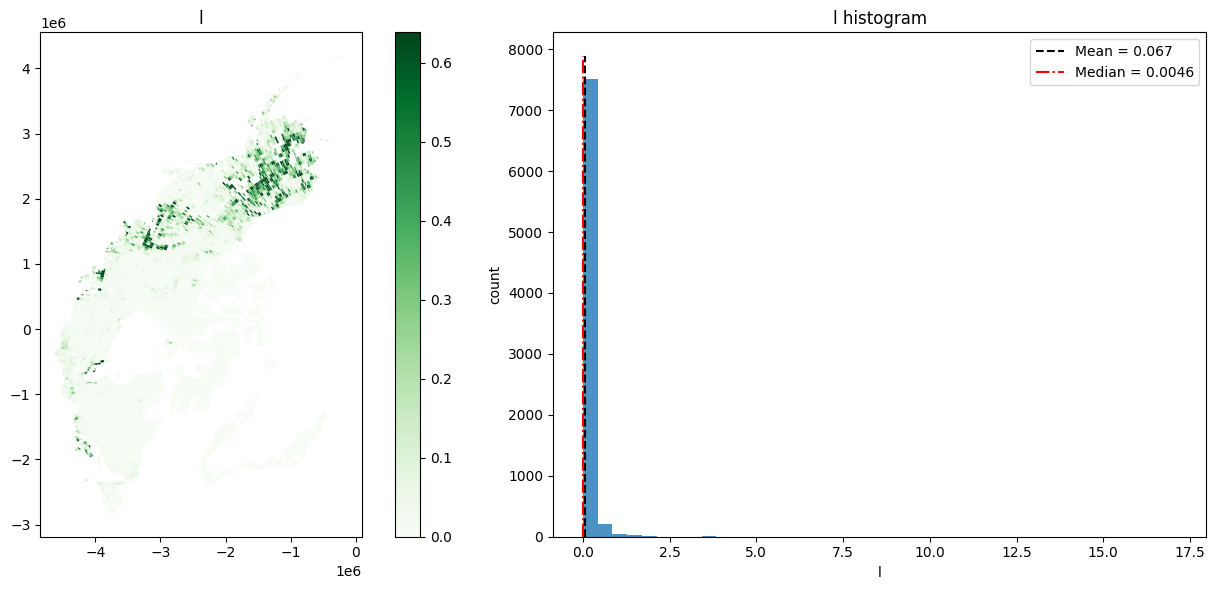

In [57]:
_, _ = plot_choro_and_hist(gdf_regridded_c, "l", hist_stats=True)

How does my LEV estimate compare to Liu 2025?

In [235]:
gdf_regridded_cp = gdf_regridded.copy()

In [236]:
# clip LEV_p1, LEV_p2, LEV_p3 to [0, 100]
# more not needed thanks to code that computes extents below
# cols = ["LEV_p1", "LEV_p2", "LEV_p3", "LEV_p3_weighted"]
cols = ["LEV_p3_liu_regrid", "AV_Occ_p3_liu_regrid"]
gdf_regridded_cp[cols] = gdf_regridded_cp[cols].clip(0, 100)

In [237]:
# rm outliers for plotting ease
for col in ["LEV_p13ain", "LEV_p13rin"]:
    low, high = gdf_regridded_cp[col].quantile([0.02, 0.98])
    gdf_regridded_cp.loc[(gdf[col] < low) | (gdf_regridded_cp[col] > high), col] = np.nan

KeyError: 'LEV_p13ain'

<Axes: xlabel='LEV_MEAN_frac_k23', ylabel='AV_Occ_p3_liu_regrid'>

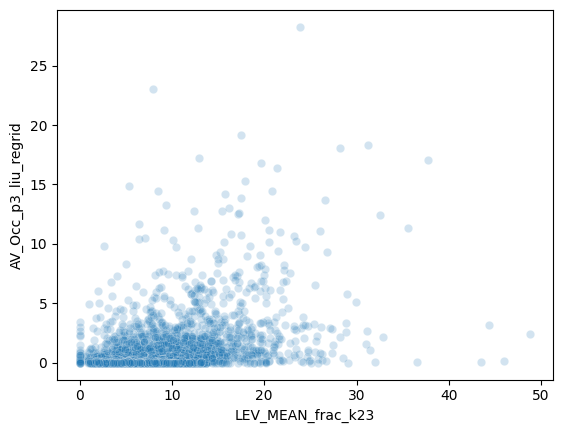

In [238]:
sns.scatterplot(gdf_regridded_cp, x="LEV_MEAN_frac_k23", y="AV_Occ_p3_liu_regrid", alpha=0.2)

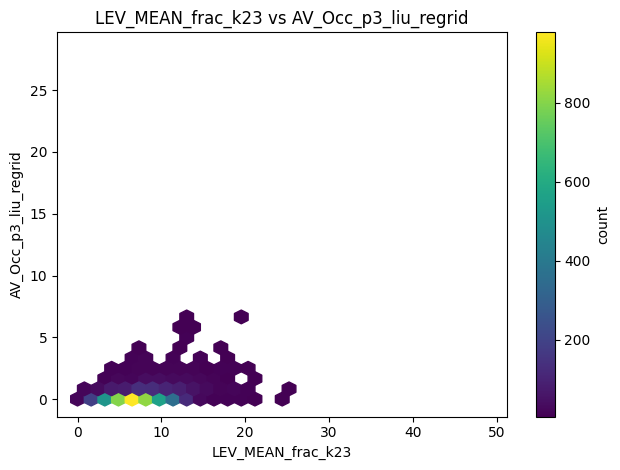

In [239]:
reg_hexplot(gdf_regridded_cp, xvar="LEV_MEAN_frac_k23", yvar="AV_Occ_p3_liu_regrid", mincnt=5)

## Lake expansion
Differs from notebooks/joins/GLAKES_join.ipynb, because here I'm considering all NA ABZ lakes


As lake objects

In [281]:
_gdf_points["lake_area_change_p2p3"] = _gdf_points["area_2010_2019_wm"] - _gdf_points["area_2000_2009_wm"]

Text(0.5, 1.0, 'GLAKES lake area change for North American ABZ, 2000–2019\nSum: 398 km2 (0.07%)')

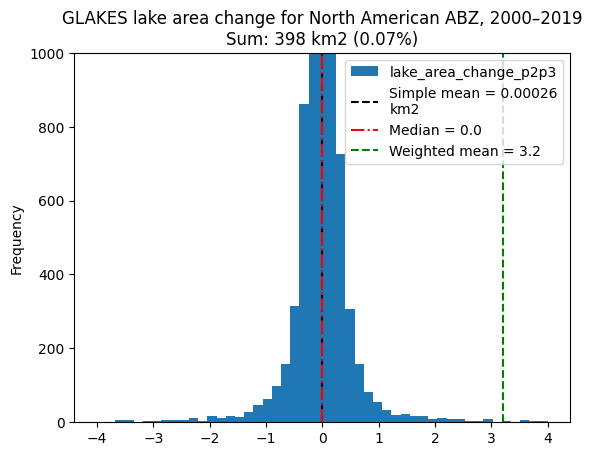

In [330]:
_gdf_points["lake_area_change_p2p3"].plot.hist(bins=np.linspace(-4, 4, 50))
# plt.yscale("log")
plt.ylim([0, 1000])
mean = _gdf_points["lake_area_change_p2p3"].mean()
plt.vlines(mean, 0, 1000, "k", "--", label=f"Simple mean = {mean:0.2}\nkm2")
med = _gdf_points["lake_area_change_p2p3"].median()
plt.vlines(med, 0, 1000, "r", "-.", label=f"Median = {med:0.2}")
# returns nan...
# wt_mean = np.average(
#     _gdf_points["lake_area_change_p2p3"], weights=_gdf_points["Area_PW_glakes"]
# )
wt_mean = np.sum(_gdf_points["Area_PW_glakes"] * _gdf_points["lake_area_change_p2p3"]) / np.sum(
    _gdf_points["Area_PW_glakes"]
)
plt.vlines(wt_mean, 0, 1000, "g", "--", label=f"Weighted mean = {wt_mean:0.2}")
plt.legend()
sum = _gdf_points['lake_area_change_p2p3'].sum()
plt.title((
    "GLAKES lake area change for North American ABZ, 2000–2019\n"
    f"Sum: {sum:0.3g} km2 ({sum / _gdf_points['Area_PW_glakes'].sum():0.2%})")
)

As grid cells

In [241]:
gdf_regridded_cp["lake_area_change_p2p3"] = gdf_regridded_cp["area_2010_2019_wm"] - gdf_regridded_cp["area_2000_2009_wm"]

Text(0.5, 1.0, 'GLAKES gridded lake area change for North American ABZ, 2000–2019')

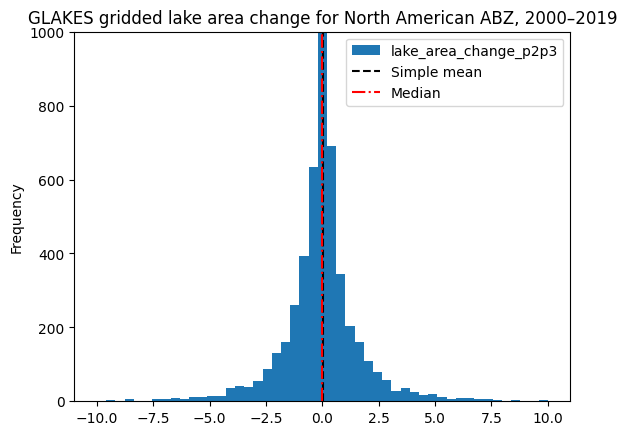

In [286]:
gdf_regridded_cp["lake_area_change_p2p3"].plot.hist(bins=np.linspace(-10, 10, 50))
# plt.yscale("log")
plt.ylim([0, 1000])
plt.vlines(gdf_regridded_cp["lake_area_change_p2p3"].mean(), 0, 1000, 'k', '--', label="Simple mean")
plt.vlines(
    gdf_regridded_cp["lake_area_change_p2p3"].median(), 0, 1000, "r", "-.", label="Median"
)
plt.legend()
plt.title("GLAKES gridded lake area change for North American ABZ, 2000–2019")

<Axes: ylabel='Frequency'>

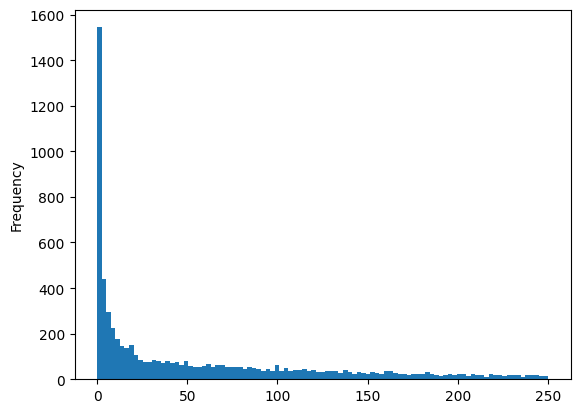

In [258]:
gdf_regridded_cp["area_2010_2019_wm"].plot.hist(bins=np.linspace(0.001, 250, 100))

## Test LEV conversion
Area_bound_glakes seems to be the best way to convert to LEV...\
Jinying: "I think this might be caused by calculation method [using lat to area conversion]."

In [334]:
(_gdf_points["areaP3"] / _gdf_points["Area_PW_glakes"]).describe()

count    331815.000000
mean          0.330552
std           0.832648
min           0.000000
25%           0.012750
50%           0.076702
75%           0.274890
max          19.035135
dtype: float64

In [336]:
(_gdf_points["areaP3"] / _gdf_points["area_2010_2019_wm"]).describe()

/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    3.312560e+05
mean              inf
std               NaN
min      0.000000e+00
25%      1.273443e-02
50%      8.046351e-02
75%      4.060635e-01
max               inf
dtype: float64

In [ ]:
(_gdf_points["areaP3"] / _gdf_points["Area_bound_glakes"]).describe()

count    331823.000000
mean          0.164261
std           0.230510
min           0.000000
25%           0.011147
50%           0.061966
75%           0.204953
max           1.301784
dtype: float64